# Descargar datos

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# datos luz
url = 'drive url'
output = 'raw_data.csv'
gdown.download(url, output, quiet=False)

df_raw = pd.read_csv(output)
print(df_raw.head())


Downloading...
From: https://drive.google.com/uc?id=1xizVxMvHHwX1mN2jU7I2dFeBRGKTvMJl
To: /content/raw_data.csv
100%|██████████| 34.4M/34.4M [00:00<00:00, 79.6MB/s]


        Fecha              Municipio  Cantidad_de_pixeles  Suma_de_radianza  \
0  2012-01-19         alvaro obregon                  380          100965.0   
1  2012-01-19                tlahuac                  356           87774.0   
2  2012-01-19           azcapotzalco                  134           48673.0   
3  2012-01-19               coyoacan                  224           94591.0   
4  2012-01-19  cuajimalpa de morelos                  272           40099.0   

   Media_de_radianza  Desviacion_estandar_de_radianza  Maximo_de_radianza  \
0         265.697368                       185.684567               914.0   
1         246.556180                        90.867169               488.0   
2         363.231343                        28.489305               448.0   
3         422.281250                       114.062508               991.0   
4         147.422794                       167.890418               779.0   

   Minimo_de_radianza  Percentil_25_de_radianza  Percentil_50_

In [ ]:
# datos pib
url = 'drive url'
output = 'pib_data.csv'
gdown.download(url, output, quiet=False)

pib_df_raw = pd.read_csv(output)
print(pib_df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1YNYTcVZ1UoGH_LeIE0cW24JMyaq7zUDa
To: /content/pib_data.csv
100%|██████████| 92.7k/92.7k [00:00<00:00, 79.7MB/s]

        fecha     municipio entidad_federativa  porc_pob       pibe  \
0  2004-03-31  Azcapotzalco               CDMX   0.04845  2226949.7   
1  2004-06-30  Azcapotzalco               CDMX   0.04845  2234735.2   
2  2004-09-30  Azcapotzalco               CDMX   0.04845  2244809.2   
3  2004-12-31  Azcapotzalco               CDMX   0.04845  2260342.1   
4  2005-03-31  Azcapotzalco               CDMX   0.04845  2258091.6   

         pib_mun  
0  107895.004216  
1  108272.209213  
2  108760.291307  
3  109512.855369  
4  109403.819360  


# Preprocessing de datos de luz

In [ ]:
# 1. quitar fechas duplicadas
df_clean = df_raw.drop_duplicates()

In [ ]:
# 2. reemplazar fecha de mala captura:
df_clean = df_clean.reset_index(drop=True)
outlier_index = df_clean.Suma_de_radianza.idxmax()
for categoria in df_clean.columns[3:]:
 prev_val = df_clean.loc[outlier_index - 1, categoria]
 next_val = df_clean.loc[outlier_index + 1, categoria]
 replacement = (prev_val + next_val) / 2
 df_clean.loc[outlier_index, categoria] = replacement



In [ ]:
target_date = pd.Timestamp('2024-06-17')
df_clean['Fecha'] = pd.to_datetime(df_clean['Fecha'])

for municipio, grupo in df_clean.groupby('Municipio'):

    mask = grupo['Fecha'] == target_date
    if not mask.any():
        continue

    outlier_index = grupo.index[mask][0]

    for categoria in df_clean.columns[3:]:

        idx_pos = grupo.index.get_loc(outlier_index)

        if idx_pos > 0 and idx_pos < len(grupo) - 1:
            prev_val = grupo.iloc[idx_pos - 1][categoria]
            next_val = grupo.iloc[idx_pos + 1][categoria]
            replacement = np.nanmean([prev_val, next_val])
            df_clean.loc[outlier_index, categoria] = replacement


/tmp/ipython-input-2060782612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Fecha'] = pd.to_datetime(df_clean['Fecha'])


In [ ]:
municipios = df_clean['Municipio'].unique()

In [ ]:
df_clean.columns[3:]

Index(['Suma_de_radianza', 'Media_de_radianza',
       'Desviacion_estandar_de_radianza', 'Maximo_de_radianza',
       'Minimo_de_radianza', 'Percentil_25_de_radianza',
       'Percentil_50_de_radianza', 'Percentil_75_de_radianza'],
      dtype='object')

In [ ]:
# evitar ceros
df_clean = df_clean.replace(0,0.001)

Queremos extraer el componente trend de cada serie, es decir, quitar la seasonality. Esto lo tenemos que hacer municipio a municipio, ya que tienen comportamiento diferente.

Datos sin seasonality

In [ ]:
# 3. Series sin trend

n_cols = len(df_clean.columns[3:])
df_list = []

#hacer trend por municipio
for municipio in municipios:

  # hacer trend por categoria
  df = df_clean[df_clean.Municipio == municipio]
  lista_series = []

  for categoria in df_clean.columns[3:]:
    series = df[categoria]
    result = seasonal_decompose(series, period=365, model='multiplicative') # periodo anual, tmb puede ser trimestral (period =90 )
    categoria = result.trend  # extraer componente trend (mantiene NaNs)
    lista_series.append(categoria)

  df_no_trend = pd.DataFrame({
    'fecha': df.Fecha,
    'municipio': df.Municipio,
    'total_pixeles': df.Cantidad_de_pixeles,
    'suma_rad_trend': lista_series[0].values,
    'media_rad_trend': lista_series[1].values,
    'std_rad_trend': lista_series[2].values,
    'max_rad_trend': lista_series[3].values,
    'min_rad_trend':lista_series[4].values,
    'p25_rad_trend': lista_series[5].values,
    'mediana_rad_trend': lista_series[6].values,
    'p75_rad_trend': lista_series[7].values
  })

  df_list.append(df_no_trend)


df_trend = pd.concat(df_list, ignore_index=True)



Los Na estan antes de cierta fecha y despues, los tenemos que llenar. Las fechas que faltan son las del primer año y las del ultimo

In [ ]:
missing_dates = df_trend[df_trend.suma_rad_trend.isna()].fecha
pd.to_datetime(missing_dates).dt.year.unique()


array([2012, 2024], dtype=int32)

In [ ]:
# 4. LLenar nulos

df_trend['fecha'] = pd.to_datetime(df_trend['fecha'])
df_trend['year'] = df_trend['fecha'].dt.year

first_year, last_year = pd.to_datetime(missing_dates).dt.year.unique()
cols_to_fill = df_trend.columns[3:]

def llenar_nulos(group):

    # backfill el año 2012
    mask_first = group['year'] == first_year
    group.loc[mask_first, cols_to_fill] = group.loc[mask_first, cols_to_fill].bfill()

    # Forward fill el año 2024
    mask_last = group['year'] == last_year
    group.loc[mask_last, cols_to_fill] = group.loc[mask_last, cols_to_fill].ffill()

    return group

# hacer el llenado por municipio, para que no se cruzen valores entre municipios
df_nonull = df_trend.groupby('municipio', group_keys=False).apply(llenar_nulos)


/tmp/ipython-input-1028718342.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nonull = df_trend.groupby('municipio', group_keys=False).apply(llenar_nulos)


In [ ]:
missing_values = df_nonull['suma_rad_trend'].isna().astype(int)
print(sum(missing_values))

0


In [ ]:
from scipy.stats.mstats import winsorize
df_nonull['suma_rad_trend'] = winsorize(df_nonull['suma_rad_trend'], limits=[0.05, 0.05])

# Procesamiento de datos de PIB

In [ ]:
pib_df_raw.columns

Index(['fecha', 'municipio', 'entidad_federativa', 'porc_pob', 'pibe',
       'pib_mun'],
      dtype='object')

In [ ]:
pib_df_raw.columns[4:]

Index(['pibe', 'pib_mun'], dtype='object')

In [ ]:
# EXTRAER TREND
n_cols = len(pib_df_raw.columns[5:])
df_list_pib = []
municipios = pib_df_raw['municipio'].unique()


#hacer trend por municipio
for municipio in municipios:

  # hacer trend por categoria
  df = pib_df_raw[pib_df_raw.municipio == municipio]
  lista_series = []

  for categoria in pib_df_raw.columns[5:]:
    series = df[categoria]
    result = seasonal_decompose(series, period=4, model='multiplicative') # periodo anual, tmb puede ser trimestral (period =90 )
    categoria = result.trend  # extraer componente trend (mantiene NaNs)
    lista_series.append(categoria)

  df_no_trend = pd.DataFrame({
    'fecha': df.fecha,
    'municipio': df.municipio,
    'entidad_federativa': df.entidad_federativa,
    'porc_pob': df.porc_pob,
    'pibe': df.pibe,
    'pib_mun': lista_series[0].values
  })

  df_list_pib.append(df_no_trend)


df_trend_pib = pd.concat(df_list_pib, ignore_index=True)

In [ ]:
missing_dates = df_trend_pib[df_trend_pib.pib_mun.isna()].fecha
pd.to_datetime(missing_dates).dt.year.unique()


array([2004, 2023], dtype=int32)

In [ ]:
# LLENAR NULOS
df_trend_pib['fecha'] = pd.to_datetime(df_trend_pib['fecha'])
df_trend_pib['year'] = df_trend_pib['fecha'].dt.year

first_year, last_year = pd.to_datetime(missing_dates).dt.year.unique()
cols_to_fill = df_trend_pib.columns[5:]

def llenar_nulos_pib(group):

    # backfill el año 2004
    mask_first = group['year'] == first_year
    group.loc[mask_first, cols_to_fill] = group.loc[mask_first, cols_to_fill].bfill()

    # Forward fill el año 2023
    mask_last = group['year'] == last_year
    group.loc[mask_last, cols_to_fill] = group.loc[mask_last, cols_to_fill].ffill()

    return group

# hacer el llenado por municipio, para que no se cruzen valores entre municipios
df_nonull_pib = df_trend_pib.groupby('municipio', group_keys=False).apply(llenar_nulos_pib)

/tmp/ipython-input-3080385331.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nonull_pib = df_trend_pib.groupby('municipio', group_keys=False).apply(llenar_nulos_pib)


In [ ]:
missing_values = df_nonull_pib['pib_mun'].isna().astype(int)
print(sum(missing_values))

0


# PIB trimestral -> PIB diario 

In [ ]:
# codigo para convertir la serie trimestral a serie diaria

all_dates = df_nonull.fecha.unique()

#
full_df_list = []

for mun in df_nonull_pib['municipio'].unique():
    # por municipio
    df_mun = df_nonull_pib[df_nonull_pib['municipio'] == mun]

    df_daily_mun = pd.DataFrame({
        "fecha": all_dates,
        "municipio": mun,
        "entidad_federativa": df_mun['entidad_federativa'].iloc[0],  # constant
    })

    # unir con la df original (aqui hay nulls en pib_mun)
    df_daily_mun = df_daily_mun.merge(df_mun[['fecha', 'pib_mun']], on='fecha', how='left')

    full_df_list.append(df_daily_mun)


df_daily_nulls = pd.concat(full_df_list, ignore_index=True)

# interpolar
def interpolate_group(group):
    group = group.sort_values('fecha')
    group['pib_interp'] = group['pib_mun'].interpolate(method='linear')
    group['pib_nn'] = group['pib_mun'].interpolate(method='nearest')
    group['pib_interp']

    # esto es para llenar los nulos que queden de la interplonatcion
    group["pib_interp"] = group["pib_interp"].ffill().bfill()
    group["pib_nn"] = group["pib_nn"].ffill().bfill()
    return group

df_daily = df_daily_nulls.groupby('municipio', group_keys=False).apply(interpolate_group)

/tmp/ipython-input-2716091894.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_daily = df_daily_nulls.groupby('municipio', group_keys=False).apply(interpolate_group)


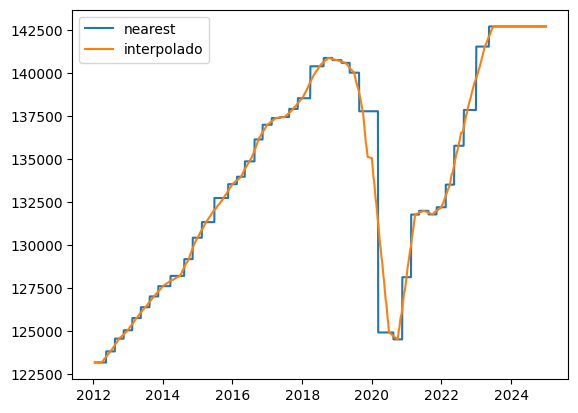

In [ ]:
series = df_daily[df_daily.municipio == 'Azcapotzalco']
plt.plot(series.fecha,series.pib_nn,label='nearest')
plt.plot(series.fecha,series.pib_interp,label='interpolado')
plt.legend()

# Union de dataframes

In [ ]:
df_daily.municipio.unique()

mapping = {
    'coyoacán': 'coyoacan',
    'álvaro obregón': 'alvaro obregon',
    'tláhuac': 'tlahuac',
    'benito juárez':'benito juarez',
    'cuauhtémoc': 'cuauhtemoc'
}

In [ ]:
# ahora que ambas df tienen el mismo numero de fechas podemos unirlas

df_daily['fecha'] = pd.to_datetime(df_daily['fecha'])
df_nonull['fecha'] = pd.to_datetime(df_nonull['fecha'])

# poner los dos en lowercase
df_daily['municipio'] = df_daily['municipio'].str.strip().str.lower()
df_nonull['municipio'] = df_nonull['municipio'].str.strip().str.lower()

mapping = {
    'coyoacán': 'coyoacan',
    'álvaro obregón': 'alvaro obregon',
    'tláhuac': 'tlahuac',
    'benito juárez':'benito juarez',
    'cuauhtémoc': 'cuauhtemoc'
}

df_daily['municipio'] = df_daily['municipio'].replace(mapping)
df_nonull['municipio'] = df_nonull['municipio'].replace(mapping)

df_pib_rad = pd.merge(
    df_daily,
    df_nonull,
    on=['fecha', 'municipio'],
    how='inner'
)


df_pib_rad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59216 entries, 0 to 59215
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               59216 non-null  datetime64[ns]
 1   municipio           59216 non-null  object        
 2   entidad_federativa  59216 non-null  object        
 3   pib_mun             656 non-null    float64       
 4   pib_interp          59216 non-null  float64       
 5   pib_nn              59216 non-null  float64       
 6   total_pixeles       59216 non-null  int64         
 7   suma_rad_trend      59216 non-null  float64       
 8   media_rad_trend     59216 non-null  float64       
 9   std_rad_trend       59216 non-null  float64       
 10  max_rad_trend       59216 non-null  float64       
 11  min_rad_trend       59216 non-null  float64       
 12  p25_rad_trend       59216 non-null  float64       
 13  mediana_rad_trend   59216 non-null  float64   

In [ ]:
df_pib_rad.to_csv("serie_rad_pib_cdmx_desestacionalizada.csv", index=False, encoding="utf-8")


aqui acaba el preprocessing

# Luz diaria -> Luz trimestral

In [ ]:
df_pib_rad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59216 entries, 0 to 59215
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               59216 non-null  datetime64[ns]
 1   municipio           59216 non-null  object        
 2   entidad_federativa  59216 non-null  object        
 3   pib_mun             656 non-null    float64       
 4   pib_interp          59216 non-null  float64       
 5   pib_nn              59216 non-null  float64       
 6   total_pixeles       59216 non-null  int64         
 7   suma_rad_trend      59216 non-null  float64       
 8   media_rad_trend     59216 non-null  float64       
 9   std_rad_trend       59216 non-null  float64       
 10  max_rad_trend       59216 non-null  float64       
 11  min_rad_trend       59216 non-null  float64       
 12  p25_rad_trend       59216 non-null  float64       
 13  mediana_rad_trend   59216 non-null  float64   

In [ ]:
df = df_pib_rad.copy()

df['fecha'] = pd.to_datetime(df['fecha'])

df['quarter'] = df['fecha'].dt.to_period('Q')

radiance_quarterly = (
    df.groupby(['municipio', 'quarter'])
      .agg({
          'total_pixeles': 'median',
          'suma_rad_trend': ['sum', 'mean', 'std','median'],
          'media_rad_trend': 'mean',
          'std_rad_trend': 'mean',
          'max_rad_trend': 'max',
          'min_rad_trend': 'min',
          'p25_rad_trend': 'mean',
          'mediana_rad_trend': 'mean',
          'p75_rad_trend': 'mean'
      })
      .reset_index()
)

radiance_quarterly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in radiance_quarterly.columns.values]

# Explicitly rename columns after reset_index
radiance_quarterly = radiance_quarterly.rename(columns={'municipio_': 'municipio', 'quarter_': 'quarter'})


# merge
df_quarterly = (
    df[['municipio', 'quarter', 'pib_mun']]
    .dropna(subset=['pib_mun'])
    .merge(radiance_quarterly, on=['municipio', 'quarter'], how='inner')
)


df_quarterly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype        
---  ------                  --------------  -----        
 0   municipio               656 non-null    object       
 1   quarter                 656 non-null    period[Q-DEC]
 2   pib_mun                 656 non-null    float64      
 3   total_pixeles_median    656 non-null    float64      
 4   suma_rad_trend_sum      656 non-null    float64      
 5   suma_rad_trend_mean     656 non-null    float64      
 6   suma_rad_trend_std      656 non-null    float64      
 7   suma_rad_trend_median   656 non-null    float64      
 8   media_rad_trend_mean    656 non-null    float64      
 9   std_rad_trend_mean      656 non-null    float64      
 10  max_rad_trend_max       656 non-null    float64      
 11  min_rad_trend_min       656 non-null    float64      
 12  p25_rad_trend_mean      656 non-null    float64      
 13  media

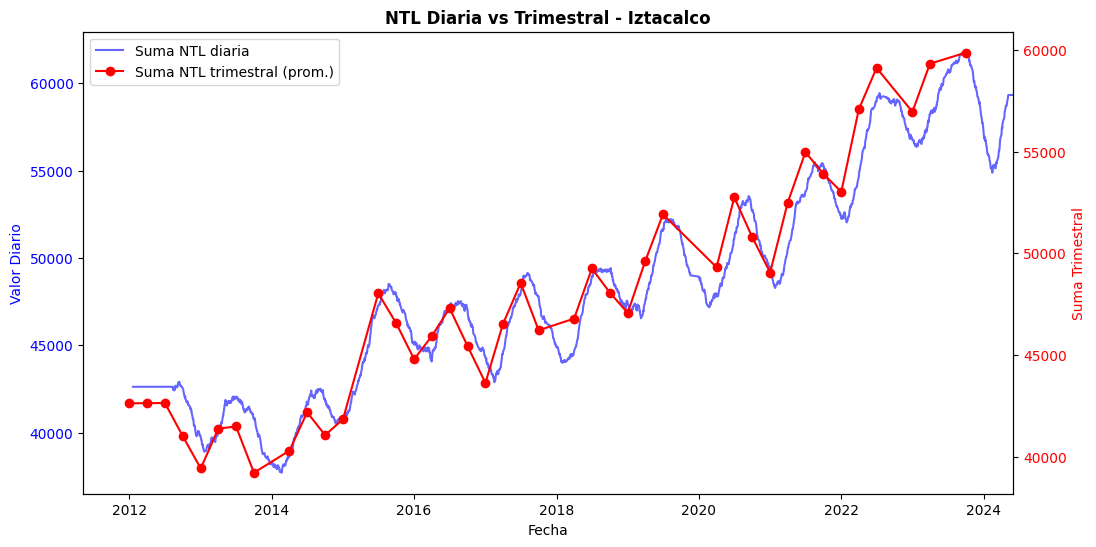

In [ ]:
#municipios = [
#    'alvaro obregon', 'azcapotzalco', 'benito juarez', 'coyoacan', 'cuajimalpa de morelos',
#    'cuauhtemoc', 'gustavo a. madero', 'iztacalco', 'iztapalapa',
#    'la magdalena contreras', 'miguel hidalgo', 'milpa alta', 'tlahuac',
#    'tlalpan', 'venustiano carranza', 'xochimilco'
#]

#var = 'suma_rad_trend_sum'
#
#for m in municipios:
#  df_mun = df_quarterly[df_quarterly['municipio'] == m]
#  plt.plot(df_mun.index,df_mun[var])
#  plt.title(var+''+m)
#  plt.show()

var_original = 'suma_rad_trend'
var_quarter = 'suma_rad_trend_mean'
m = 'iztacalco'

# Filtros originales
df_mun_d = df_pib_rad[df_pib_rad['municipio'] == m].copy() 
df_mun_q = df_quarterly[df_quarterly['municipio'] == m].copy()

df_mun_d['fecha'] = pd.to_datetime(df_mun_d['fecha'])

# Convertimos el periodo trimestral al primer día de ese trimestre

df_mun_q['fecha_inicio_q'] = df_mun_q['quarter'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_mun_d['fecha'], df_mun_d[var_original], color='blue', label='Suma NTL diaria', alpha=0.6)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Valor Diario', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje Y derecho (Datos Trimestrales) - Recomendado por la diferencia de escalas
ax2 = ax1.twinx()
ax2.plot(df_mun_q['fecha_inicio_q'], df_mun_q[var_quarter], color='red', marker='o', label='Suma NTL trimestral (prom.)')
ax2.set_ylabel('Suma Trimestral', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'NTL Diaria vs Trimestral - {m.capitalize()}',fontweight='bold')


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
fecha_fin = pd.Timestamp('2024-06-01')
ax1.set_xlim(right=fecha_fin)

plt.show()



In [ ]:
df_quarterly.to_csv("serie_trimestral_cdmx_desestacionalizada_agg.csv", index=False, encoding="utf-8")

# Trimestral, pero con inner join

In [ ]:
df_nonull['fecha'] = pd.to_datetime(df_nonull['fecha'])
df_nonull_pib['municipio'] = df_nonull_pib['municipio'].str.strip().str.lower()

df_nonull_pib['fecha'] = pd.to_datetime(df_nonull_pib['fecha'])

df_nonull_pib['municipio'] = df_nonull_pib['municipio'].replace(mapping)

merged_df = pd.merge(
    df_nonull_pib,
    df_nonull,
    on=['fecha','municipio'],
    how='inner',  # solo fechas comunes
    suffixes=('_pib', '_radianza')
)

merged_df.to_csv("serie_trimestral_cdmx_desestacionalizada(sin agg).csv", index=False, encoding="utf-8")